### The following code is copied from Roi Nevo's github and reproduces Configuration A (as seen in Fig. 4 of NV draft)

In [1]:
%run bath_functions.ipynb

In [2]:
a = 5
key = random.PRNGKey(a)
Jmax = 1.0
alpha = 3.0
Gamma = 0.1
d_min = 0.5

R = 16/ d_min
sigma  = 0.01
N= int(round(sigma * R**2))
N


10

a=5


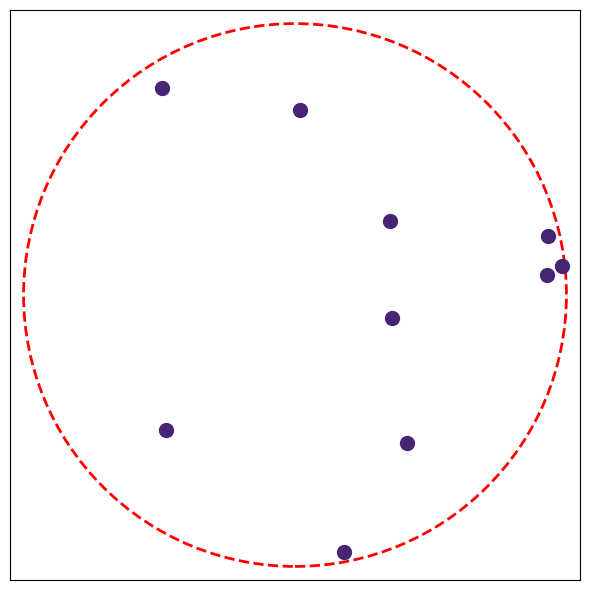

In [3]:
print(f'a={a}')

key = random.PRNGKey(a)


positions = random_bath_positions(key, radius=R, num_particles=N, dim=2)
rho0 = jnp.zeros((N, N), dtype=jnp.complex128).at[0, 0].set(1.0)  # ← Add dtype
tlist =  jnp.geomspace(1, 10**9,1000)
H, sort_order = Hampl_geometric(key, positions, Jmax, alpha, double_precision=True)
L = lindbladmatpl(H, Gamma, double_precision=True)
rhos = evolve_rho_over_time(L, rho0, tlist, double_precision=True)

plot_rho_geometric_frame(rhos[-int(0.1*len(tlist))], positions[sort_order], 
                        coherence_percentile=-1.0000, 
                        title="", 
                        radius=R)

In [9]:
print(positions)
print(H)

[[ 11.22998167   8.6657443 ]
 [ 29.78424968   6.90942031]
 [ 31.53553015   3.44199744]
 [ 29.69692277   2.38201959]
 [  5.82726916 -30.27930513]
 [ 13.21948377 -17.481802  ]
 [-15.69793743  24.45663107]
 [-15.20226319 -15.91983595]
 [ 11.4583447   -2.66983921]
 [  0.64608129  21.77132371]]
[[0.00000000e+00+0.j 1.04615989e-01+0.j 1.70594859e-02+0.j
  1.08494889e-04+0.j 1.08182783e-04+0.j 4.65042193e-05+0.j
  2.15801123e-05+0.j 1.31159768e-05+0.j 7.72356342e-06+0.j
  7.23761251e-06+0.j]
 [1.04615989e-01+0.j 0.00000000e+00+0.j 1.07698802e-02+0.j
  1.34724185e-04+0.j 1.47527041e-04+0.j 5.81718598e-05+0.j
  2.34701313e-05+0.j 1.51048713e-05+0.j 8.77304188e-06+0.j
  7.77509164e-06+0.j]
 [1.70594859e-02+0.j 1.07698802e-02+0.j 0.00000000e+00+0.j
  1.54474721e-04+0.j 1.13094614e-04+0.j 3.90146844e-05+0.j
  2.85745711e-05+0.j 1.15513922e-05+0.j 7.78893771e-06+0.j
  8.63145411e-06+0.j]
 [1.08494889e-04+0.j 1.34724185e-04+0.j 1.54474721e-04+0.j
  0.00000000e+00+0.j 6.86126234e-04+0.j 5.54557590e-0

In [6]:
print(positions)

[[ 11.22998167   8.6657443 ]
 [ 29.78424968   6.90942031]
 [ 31.53553015   3.44199744]
 [ 29.69692277   2.38201959]
 [  5.82726916 -30.27930513]
 [ 13.21948377 -17.481802  ]
 [-15.69793743  24.45663107]
 [-15.20226319 -15.91983595]
 [ 11.4583447   -2.66983921]
 [  0.64608129  21.77132371]]


### The code below is mine, and converts hamiltonian (H) from Roi into a sympy matrix in terms of epsilon (coupling strength between pairs 0,2 and 1,2)

In [88]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

/opt/conda/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
epsilon = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)

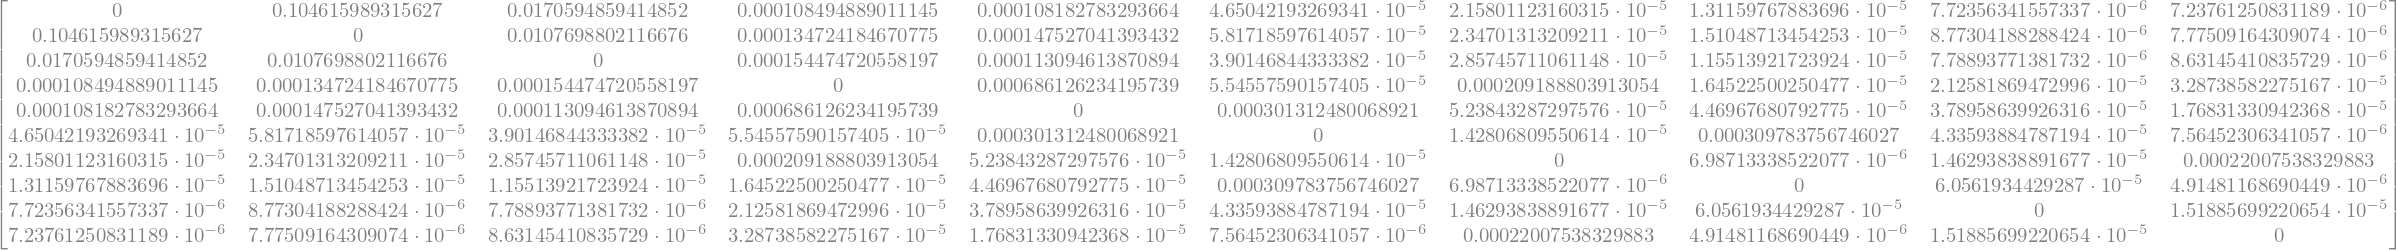

In [6]:
H_sympy = sp.Matrix(H)
H_sympy

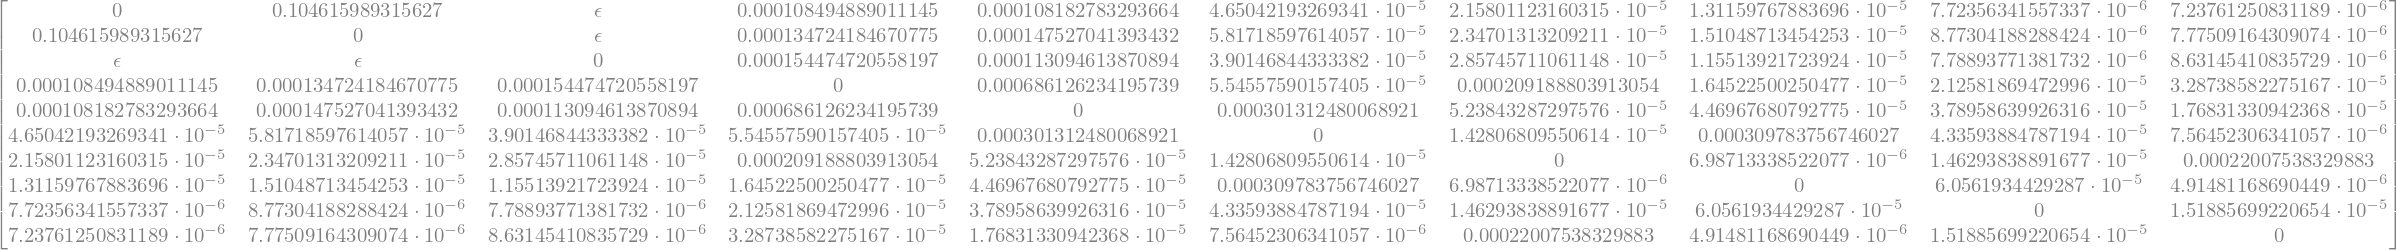

In [7]:
H_sympy[2, 0] = epsilon
H_sympy[0, 2] = epsilon
H_sympy[2, 1] = epsilon
H_sympy[1, 2] = epsilon

H_sympy

In [23]:
L, rho = lindbladian(H=H_sympy)

In [25]:
# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(10)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(10) for j in range(10)})

In [1]:
# now sending this to Mathematica for numeric eval computations
mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ").replace("e", "*10^")

NameError: name 'mathematica_code' is not defined

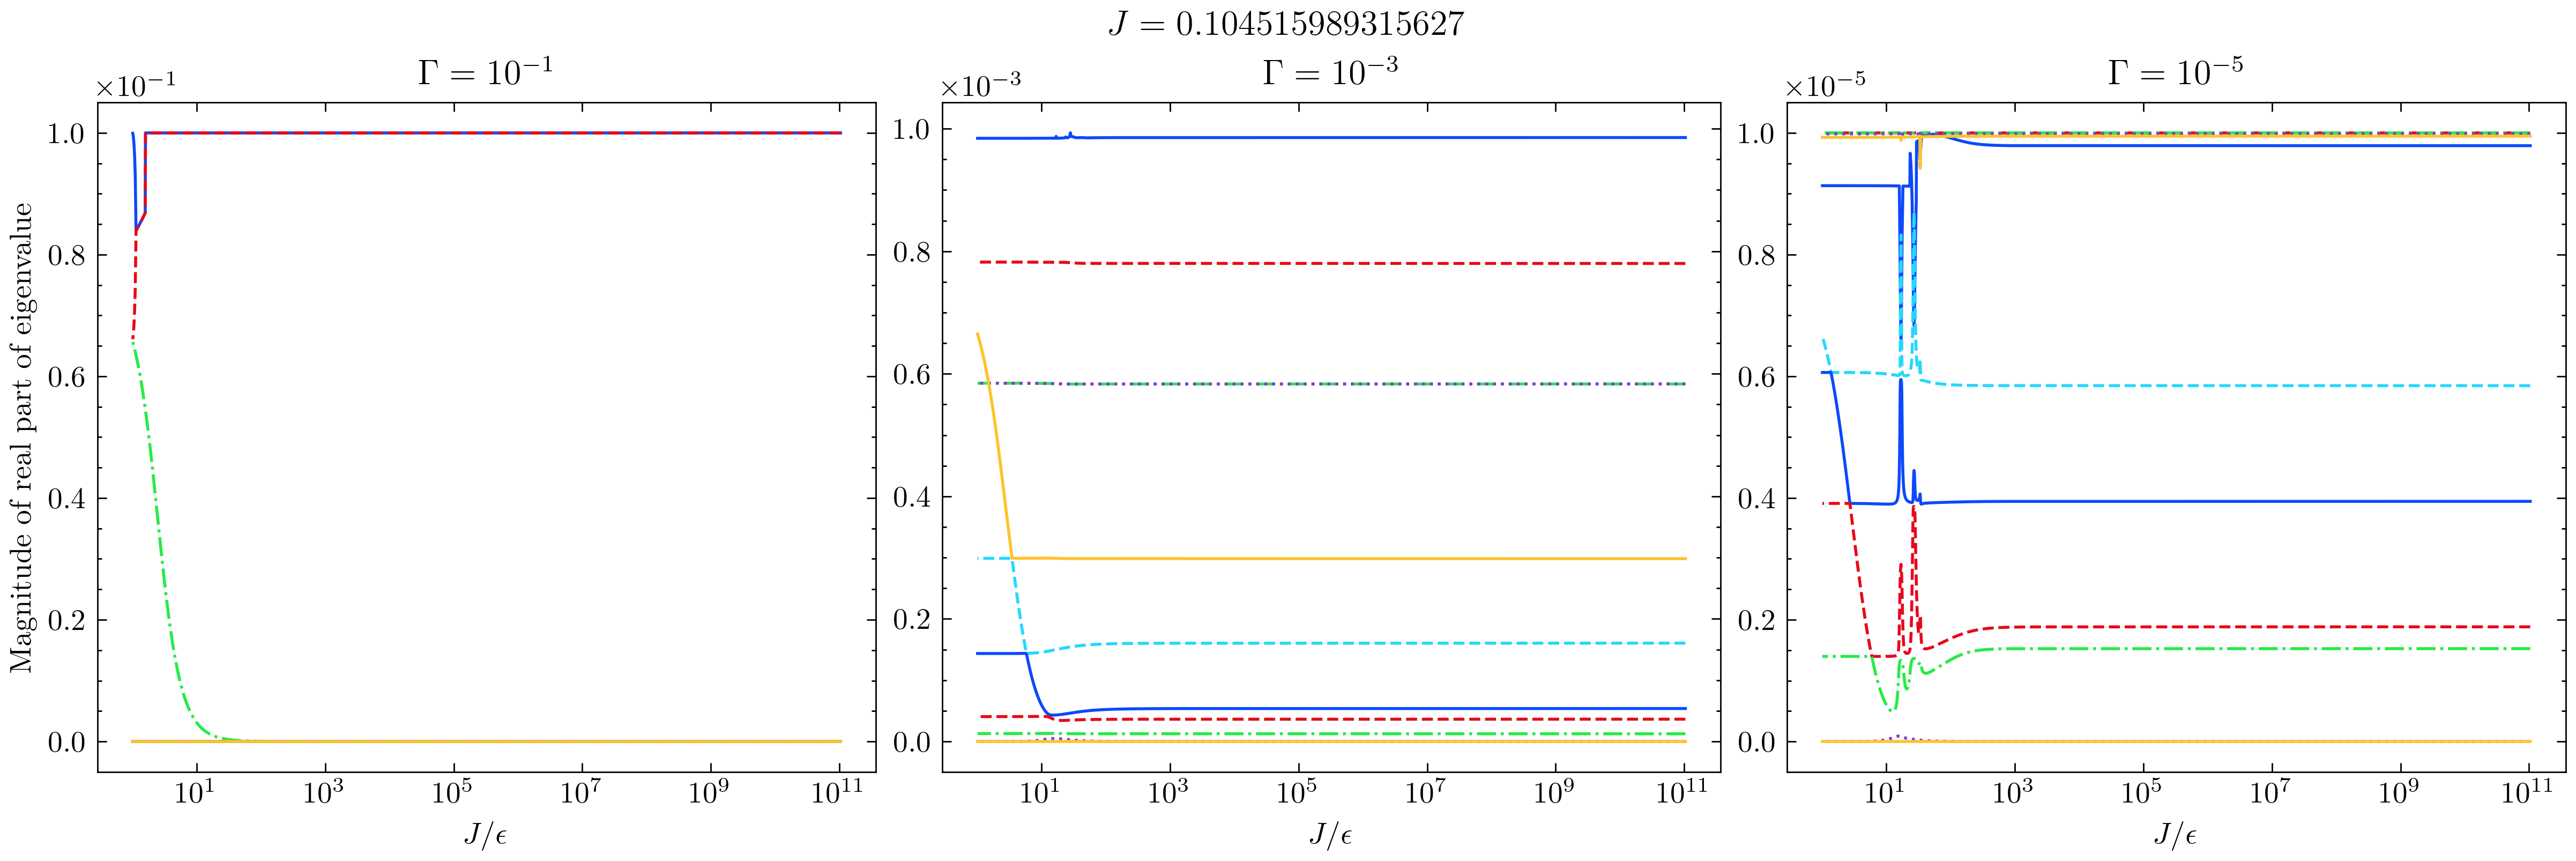

In [90]:
J_val = 0.104515989315627

datas = [
    np.loadtxt("gamma=1e-1 A.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-3 A.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-5 A.dat", dtype=np.complex128)
]
gammas = [
    1e-1,
    1e-3,
    1e-5
]


fig, axs = plt.subplots(1,3, figsize=(12, 4), layout='constrained')
plt.style.use(['science', 'high-vis'])



        
for col, data in enumerate(datas):
    eps = data[:, 0]
    evals = data[:, 90:]
    
    for i in range(evals.shape[1]):
        axs[col].plot(J_val/eps,
                       np.abs(evals[:, i]),
                        label=f"{i+1}",
                        #linewidth=2.75*0.95**i,
                        #alpha=1*0.9**i
                     )

    #axs[col].legend(title='Eigenvalue No.:', title_fontsize=12, fontsize=9, ncol=3, loc=(0.3, 0.2)) # plotting legend
    axs[col].set_xscale('log') # setting log scale for x axis
    axs[col].set_xlabel(r"$J / \epsilon$") # labelling x axis
    #axs[col].invert_xaxis() # inverting x axis
    axs[col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    #axs[col].set_yscale('symlog') # setting log scale for y axis
    #axs[col].set_ylim([-1*gammas[col]*0.2, gammas[col]*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gammas[col]))}}}$')

axs[0].set_ylabel('Magnitude of real part of eigenvalue')  # labelling y axis
fig.suptitle(fr'$J={J_val}$')      
fig.savefig("splitting.pdf")


In [81]:
np.real(datas[0][:, 0])

array([1.00000000e-12, 1.01000000e-12, 1.02010000e-12, ...,
       1.01517058e-01, 1.02532229e-01, 1.03557551e-01], shape=(2550,))

In [67]:
np.shape(np.unique(datas[0].round(decimals=7), axis=1))

In [85]:
np.shape(datas[2])

In [52]:
a = np.array( [ [0,3,3,7],
                [1,3,3,3],
                [2,2,2,5]] )
np.unique(a, axis=1)

array([[0, 3, 7],
       [1, 3, 3],
       [2, 2, 5]])

In [25]:
np.unique(datas[0].round(decimals=7), axis=1)[:, 0]

array([-0.001    +0.j, -0.001    +0.j, -0.001    +0.j, ...,
       -0.0009999+0.j, -0.0009999+0.j, -0.0009999+0.j], shape=(2315,))